  DELTA-V BUDGET PER STRATEGY (LEO -> GEO)
Strategy 1 (3-Impulse):           5.983 km/s
Strategy 2 (Full Perigee):        8.064 km/s
Strategy 3 (Full Apogee):         4.499 km/s
Strategy 4 (Optimal Split):       4.461 km/s
--------------------------------------------------------
  STRATEGY 4 OPTIMAL CONFIGURATION:
  -> Fraction at Perigee (s):     6.64 %
  -> Fraction at Apogee (1-s):    93.36 %
--------------------------------------------------------
  STRATEGY 4 SAVINGS COMPARISON:
  vs Strategy 1: -1.521 km/s (-25.4%)
  vs Strategy 2: -3.603 km/s (-44.7%)
  vs Strategy 3: -0.038 km/s (-0.8%)

Propagating LEO orbit for 30 days with full perturbations...

  ORBITAL PARAMETERS EVOLUTION (0 -> 30 DAYS)
SMA:   6978.000 km  -->  6973.540 km  | Delta:   -4.460 km
ECC:   0.000000     -->  0.001944     | Delta: 0.001943
INC:    42.0000 deg -->   41.9438 deg | Delta:  -0.0562 deg
RAAN:    0.0000 deg -->  196.9712 deg | Delta: -163.0288 deg
AOP:     0.0000 deg -->   76.8839 deg | Delta:  76.88

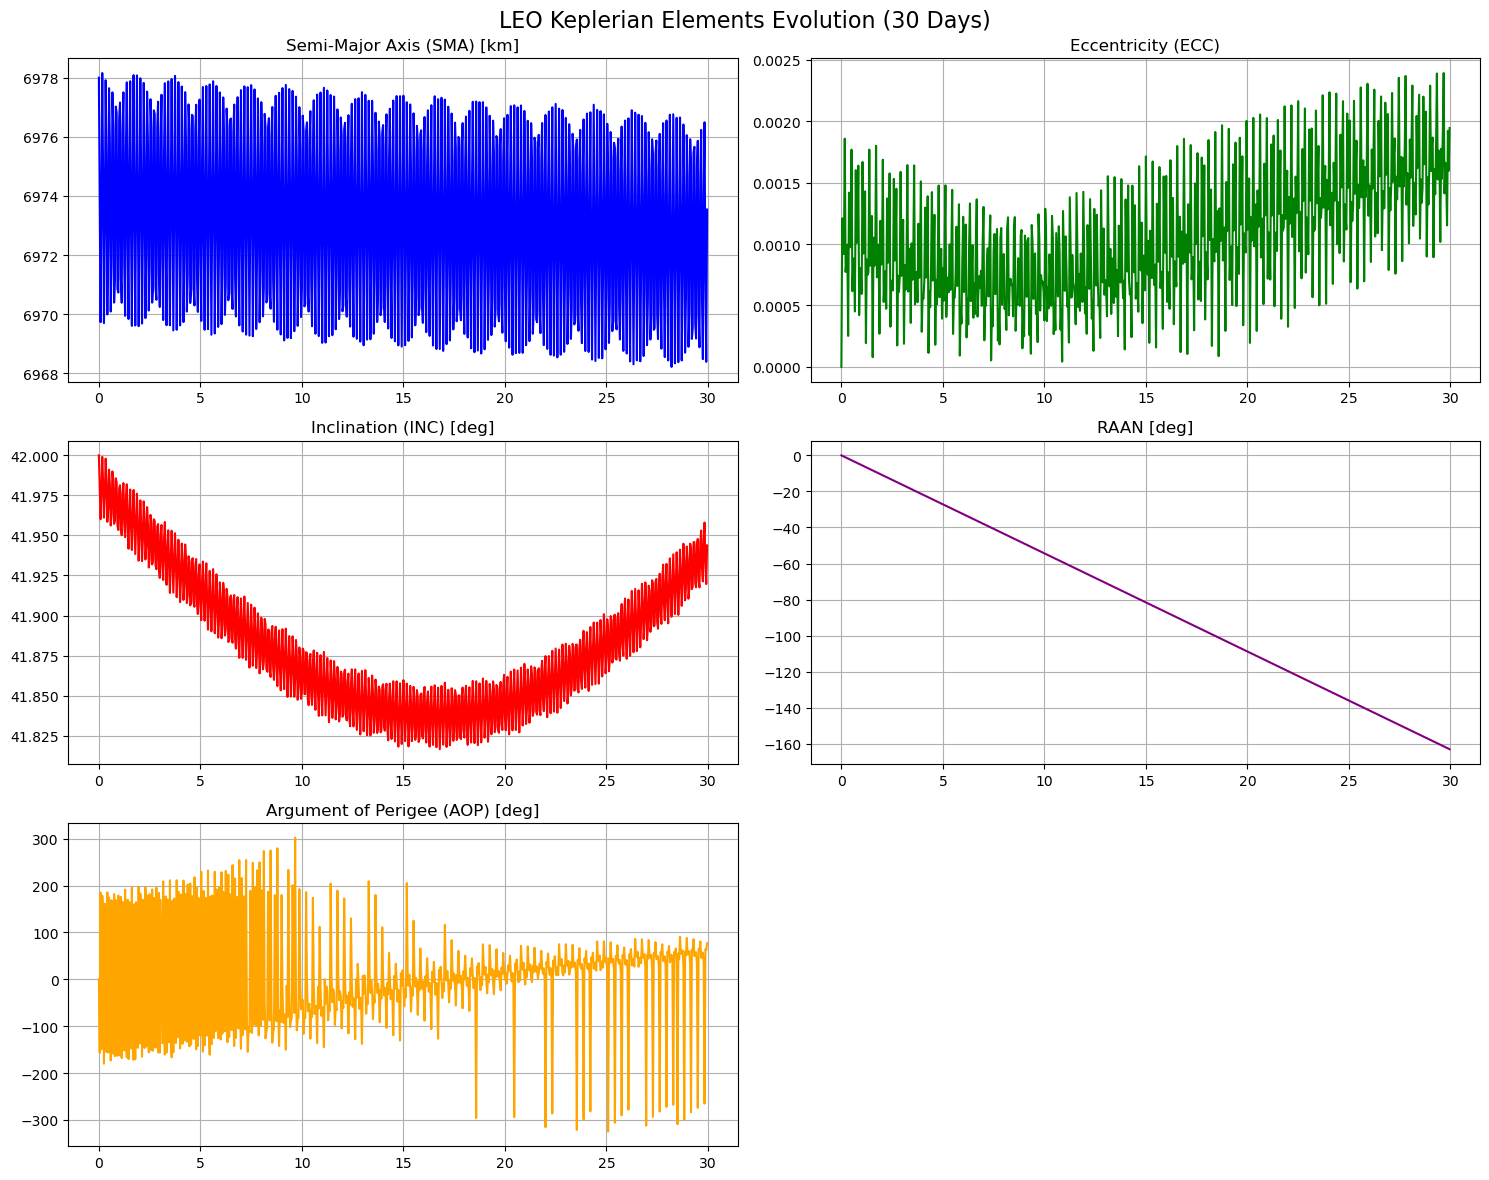

Simulation complete. Data saved.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import orekit
from orekit.pyhelpers import setup_orekit_curdir, datetime_to_absolutedate
from datetime import datetime

# Import Orekit classes
from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.numerical import NumericalPropagator
from org.orekit.propagation import SpacecraftState
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel, ThirdBodyAttraction
from org.orekit.forces.drag import DragForce, IsotropicDrag
from org.orekit.models.earth.atmosphere import HarrisPriester
from org.orekit.bodies import CelestialBodyFactory, OneAxisEllipsoid
from org.orekit.forces.radiation import SolarRadiationPressure, IsotropicRadiationSingleCoefficient
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from orekit import JArray_double

# ==========================================
# 1. OREKIT ENVIRONMENT INITIALIZATION
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

# Earth's gravitational parameter [km^3/s^2]
mu_E = Constants.WGS84_EARTH_MU / 1e9  

# ==========================================
# 2. MISSION PARAMETERS
# ==========================================
r_LEO = 6978.0  # Initial LEO radius [km]
r_GEO = 42164.0 # Target GEO radius [km]
inc_change = np.radians(42.0) # Inclination change [rad]

v_LEO = np.sqrt(mu_E / r_LEO)
v_GEO = np.sqrt(mu_E / r_GEO)

# Transfer ellipse geometry
a_tr = (r_LEO + r_GEO) / 2.0
v_p_tr = np.sqrt(mu_E * (2/r_LEO - 1/a_tr)) # Velocity at perigee of transfer orbit
v_a_tr = np.sqrt(mu_E * (2/r_GEO - 1/a_tr)) # Velocity at apogee of transfer orbit

# ==========================================
# 3. DELTA-V STRATEGIES ANALYSIS & SAVINGS
# ==========================================

# Strategy 1: 3-Impulse (Hohmann + Separate Plane Change at GEO)
dv1_1 = v_p_tr - v_LEO
dv2_1 = v_GEO - v_a_tr
dv3_1 = 2 * v_GEO * np.sin(inc_change / 2)
dv_strat1 = dv1_1 + dv2_1 + dv3_1

# Strategy 2: Full Plane Change at Perigee (s=1)
dv1_2 = np.sqrt(v_LEO**2 + v_p_tr**2 - 2*v_LEO*v_p_tr*np.cos(inc_change))
dv2_2 = v_GEO - v_a_tr
dv_strat2 = dv1_2 + dv2_2

# Strategy 3: Full Plane Change at Apogee (s=0)
dv1_3 = v_p_tr - v_LEO
dv2_3 = np.sqrt(v_GEO**2 + v_a_tr**2 - 2*v_GEO*v_a_tr*np.cos(inc_change))
dv_strat3 = dv1_3 + dv2_3

# Strategy 4: Split Plane Change (Optimizing fraction 's')
def split_plane_dv(s):
    alpha_1 = s * inc_change
    alpha_2 = (1 - s) * inc_change
    dv1 = np.sqrt(v_LEO**2 + v_p_tr**2 - 2*v_LEO*v_p_tr*np.cos(alpha_1))
    dv2 = np.sqrt(v_GEO**2 + v_a_tr**2 - 2*v_GEO*v_a_tr*np.cos(alpha_2))
    return dv1 + dv2

result = minimize_scalar(split_plane_dv, bounds=(0, 1), method='bounded')
s_opt = result.x
dv_strat4 = result.fun

# Savings Calculations vs Strategy 4
sav_abs_1 = dv_strat4 - dv_strat1
sav_rel_1 = (sav_abs_1 / dv_strat1) * 100

sav_abs_2 = dv_strat4 - dv_strat2
sav_rel_2 = (sav_abs_2 / dv_strat2) * 100

sav_abs_3 = dv_strat4 - dv_strat3
sav_rel_3 = (sav_abs_3 / dv_strat3) * 100

print("========================================================")
print("  DELTA-V BUDGET PER STRATEGY (LEO -> GEO)")
print("========================================================")
print(f"Strategy 1 (3-Impulse):           {dv_strat1:.3f} km/s")
print(f"Strategy 2 (Full Perigee):        {dv_strat2:.3f} km/s")
print(f"Strategy 3 (Full Apogee):         {dv_strat3:.3f} km/s")
print(f"Strategy 4 (Optimal Split):       {dv_strat4:.3f} km/s")
print("--------------------------------------------------------")
print("  STRATEGY 4 OPTIMAL CONFIGURATION:")
print(f"  -> Fraction at Perigee (s):     {s_opt*100:.2f} %")
print(f"  -> Fraction at Apogee (1-s):    {(1-s_opt)*100:.2f} %")
print("--------------------------------------------------------")
print("  STRATEGY 4 SAVINGS COMPARISON:")
print(f"  vs Strategy 1: {sav_abs_1:+.3f} km/s ({sav_rel_1:+.1f}%)")
print(f"  vs Strategy 2: {sav_abs_2:+.3f} km/s ({sav_rel_2:+.1f}%)")
print(f"  vs Strategy 3: {sav_abs_3:+.3f} km/s ({sav_rel_3:+.1f}%)")
print("========================================================\n")

# ==========================================
# 4. OREKIT PROPAGATOR SETUP (30 DAYS IN LEO)
# ==========================================
utc = TimeScalesFactory.getUTC()
initial_date = datetime_to_absolutedate(datetime(2026, 1, 1, 12, 0, 0))
inertial_frame = FramesFactory.getEME2000()

# Earth frame initialization using IERS conventions
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)

# Initial LEO Orbit (Microscopic eccentricity added to prevent singular Jacobian)
orbit = KeplerianOrbit(
    float(r_LEO * 1000.0),                  # Semi-major axis [m]
    1e-7,                                   # Eccentricity (microscopic)
    float(np.radians(42.0)),                # Inclination [rad]
    0.0,                                    # Perigee Argument
    0.0,                                    # RAAN
    0.0,                                    # True Anomaly
    PositionAngleType.TRUE, 
    inertial_frame, 
    initial_date, 
    float(Constants.WGS84_EARTH_MU)
)

# 50 kg mass for A/m = 0.02 with Area = 1.0 m^2
initial_state = SpacecraftState(orbit, 50.0) 

# Numerical Integrator Configuration
min_step = 0.001
max_step = 1000.0
position_tolerance = 10.0
tolerances = NumericalPropagator.tolerances(position_tolerance, orbit, orbit.getType())
abs_tolerance = JArray_double.cast_(tolerances[0])
rel_tolerance = JArray_double.cast_(tolerances[1])
integrator = DormandPrince853Integrator(min_step, max_step, abs_tolerance, rel_tolerance)
propagator = NumericalPropagator(integrator)
propagator.setInitialState(initial_state)

# --- PERTURBATIONS SETUP ---
gravity_provider = GravityFieldFactory.getNormalizedProvider(10, 10)
propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, gravity_provider))

sun = CelestialBodyFactory.getSun()
moon = CelestialBodyFactory.getMoon()
propagator.addForceModel(ThirdBodyAttraction(sun))
propagator.addForceModel(ThirdBodyAttraction(moon))

earth_shape = OneAxisEllipsoid(Constants.WGS84_EARTH_EQUATORIAL_RADIUS, Constants.WGS84_EARTH_FLATTENING, earth_frame)
atmosphere = HarrisPriester(sun, earth_shape)
drag_force = DragForce(atmosphere, IsotropicDrag(1.0, 2.2)) 
propagator.addForceModel(drag_force)

srp = SolarRadiationPressure(sun, earth_shape, IsotropicRadiationSingleCoefficient(1.0, 1.0))
propagator.addForceModel(srp)

# ==========================================
# 5. PROPAGATION AND DATA COLLECTION
# ==========================================
print("Propagating LEO orbit for 30 days with full perturbations...\n")
duration_days = 30.0
step_time = 3600.0 # 1 hour per step
num_steps = int((duration_days * 86400) / step_time)

time_days = []
sma, ecc, inc, raan, aop = [], [], [], [], []

current_date = initial_date
final_state = None

for i in range(num_steps):
    final_state = propagator.propagate(current_date)
    orb = KeplerianOrbit(final_state.getOrbit())
    
    time_days.append(final_state.getDate().durationFrom(initial_date) / 86400.0)
    sma.append(orb.getA() / 1000.0)
    ecc.append(orb.getE())
    inc.append(np.degrees(orb.getI()))
    raan.append(np.degrees(orb.getRightAscensionOfAscendingNode()))
    aop.append(np.degrees(orb.getPerigeeArgument()))
    
    current_date = current_date.shiftedBy(step_time)

# ==========================================
# 6. ORBITAL PARAMETERS CONSOLE REPORT
# ==========================================
final_orbit = KeplerianOrbit(final_state.getOrbit())

# Extract initial values (Modulo 360 for angular coordinates)
sma_0 = orbit.getA() / 1000.0
ecc_0 = orbit.getE()
inc_0 = np.degrees(orbit.getI())
raan_0 = np.degrees(orbit.getRightAscensionOfAscendingNode()) % 360.0
aop_0 = np.degrees(orbit.getPerigeeArgument()) % 360.0

# Extract final values (Modulo 360 for angular coordinates)
sma_f = final_orbit.getA() / 1000.0
ecc_f = final_orbit.getE()
inc_f = np.degrees(final_orbit.getI())
raan_f = np.degrees(final_orbit.getRightAscensionOfAscendingNode()) % 360.0
aop_f = np.degrees(final_orbit.getPerigeeArgument()) % 360.0

# Compute Deltas (Standard subtraction for linear/bounded values)
delta_sma = sma_f - sma_0
delta_ecc = ecc_f - ecc_0
delta_inc = inc_f - inc_0

# Compute Deltas (Shortest angular path for circular coordinates)
delta_raan = (raan_f - raan_0 + 180.0) % 360.0 - 180.0
delta_aop = (aop_f - aop_0 + 180.0) % 360.0 - 180.0

print("======================================================================")
print("  ORBITAL PARAMETERS EVOLUTION (0 -> 30 DAYS)")
print("======================================================================")
print(f"SMA:  {sma_0:>9.3f} km  --> {sma_f:>9.3f} km  | Delta: {delta_sma:>8.3f} km")
print(f"ECC:  {ecc_0:>9.6f}     --> {ecc_f:>9.6f}     | Delta: {delta_ecc:>8.6f}")
print(f"INC:  {inc_0:>9.4f} deg --> {inc_f:>9.4f} deg | Delta: {delta_inc:>8.4f} deg")
print(f"RAAN: {raan_0:>9.4f} deg --> {raan_f:>9.4f} deg | Delta: {delta_raan:>8.4f} deg")
print(f"AOP:  {aop_0:>9.4f} deg --> {aop_f:>9.4f} deg | Delta: {delta_aop:>8.4f} deg")
print("======================================================================\n")

# ==========================================
# 7. ORBITAL PARAMETERS PLOTTING
# ==========================================
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('LEO Keplerian Elements Evolution (30 Days)', fontsize=16)

axes[0,0].plot(time_days, sma, color='blue')
axes[0,0].set_title('Semi-Major Axis (SMA) [km]')
axes[0,0].grid(True)

axes[0,1].plot(time_days, ecc, color='green')
axes[0,1].set_title('Eccentricity (ECC)')
axes[0,1].grid(True)

axes[1,0].plot(time_days, inc, color='red')
axes[1,0].set_title('Inclination (INC) [deg]')
axes[1,0].grid(True)

axes[1,1].plot(time_days, raan, color='purple')
axes[1,1].set_title('RAAN [deg]')
axes[1,1].grid(True)

axes[2,0].plot(time_days, aop, color='orange')
axes[2,0].set_title('Argument of Perigee (AOP) [deg]')
axes[2,0].grid(True)

axes[2,1].axis('off') # Hide the empty subplot
plt.tight_layout()
plt.savefig('orbital_perturbations_30days.png', dpi=300)
plt.show()
print("Simulation complete. Data saved.")